In [1]:
import numpy as np
from scipy.integrate import quad
from scipy.stats import norm
from scipy.optimize import root
import matplotlib.pyplot as plt

### Numerical Solution for the Critical Interaction Strength ($\mu_c$)

This section computes the critical interaction strength $\mu_c$ for the generalized Lotka-Volterra model on a network. Above this threshold in the cooperative regime ($\mu \ge \mu_c$), the average abundance $M^*$ diverges. 

According to the Heterogeneous Dynamical Mean-Field Theory (HDMFT), the critical point is found by setting the crossover degree $g_c = 0$. This requires simultaneously solving the following system of self-consistent equations for $\mu_c$, the scaled variance $q^*$, and the integrated response $\chi^*$:

**1. The Self-Consistent System:**
$$1 = \mu_c \int_0^{g^*} dg \nu(g) g \frac{\sqrt{g q^*} \sigma}{1 - g \gamma \sigma^2 \chi^*} \int_{-\Delta_g}^\infty Dz (\Delta_g + z)$$

$$1 = \int_0^{g^*} dg \nu(g) g \frac{g \sigma^2}{(1 - g \gamma \sigma^2 \chi^*)^2} \int_{-\Delta_g}^\infty Dz (\Delta_g + z)^2$$

$$\chi^* = \int_0^{g^*} dg \nu(g) g \frac{1}{1 - g \gamma \sigma^2 \chi^*} \int_{-\Delta_g}^\infty Dz$$

Where:
* $\Delta_g = \frac{g}{\sqrt{g q^*} \sigma}$
* $Dz = \frac{1}{\sqrt{2\pi}} e^{-z^2/2} dz$ (the standard Gaussian measure)
* $g^* = \frac{1}{|\gamma|\sigma^2 \chi^*}$ (the upper integration bound to prevent singularities when $\gamma > 0$)

---

#### Analytical Simplification of Inner Integrals
To avoid computationally expensive and unstable double-numerical integration, the inner integrals over the Gaussian measure $Dz$ are solved exactly. Let $\Phi(x)$ and $\phi(x)$ denote the Cumulative Distribution Function (CDF) and Probability Density Function (PDF) of the standard normal distribution, respectively. 

The inner integrals reduce to:
1. **Zeroth Moment:** $\int_{-\Delta_g}^\infty Dz = \Phi(\Delta_g)$
2. **First Moment:** $\int_{-\Delta_g}^\infty Dz (\Delta_g + z) = \Delta_g \Phi(\Delta_g) + \phi(\Delta_g)$
3. **Second Moment:** $\int_{-\Delta_g}^\infty Dz (\Delta_g + z)^2 = (\Delta_g^2 + 1)\Phi(\Delta_g) + \Delta_g \phi(\Delta_g)$

By substituting these analytical forms back into the main system, the problem is reduced to a single numerical integration over the network's continuous degree distribution $\nu(g)$, which is handled by the multi-dimensional root-finding solver below.

In [2]:
from glv.analysis import calculate_mu_c

In [3]:
# Test parameters based on the paper's examples
sigma_val = 0.5
gamma_val = 0.0 # No correlation case

# Define the exponential degree distribution: nu(g) = e^(-g)
def exponential_nu(g):
    return np.exp(-g)

print(f"Solving for sigma = {sigma_val}, gamma = {gamma_val}...")
try:
    results = calculate_mu_c(sigma=sigma_val, gamma=gamma_val, nu_pdf=exponential_nu)
    print(f"--> Critical Interaction Strength (mu_c): {results['mu_c']:.4f}")
    print(f"--> Scaled variance (q*): {results['q_star']:.4f}")
    print(f"--> Integrated response (chi*): {results['chi_star']:.4f}")
except Exception as e:
    print(f"Error: {e}")

Solving for sigma = 0.5, gamma = 0.0...
--> Critical Interaction Strength (mu_c): 0.4162
--> Scaled variance (q*): 17.3192
--> Integrated response (chi*): 0.7330


Sweeping through sigma values to build plot...


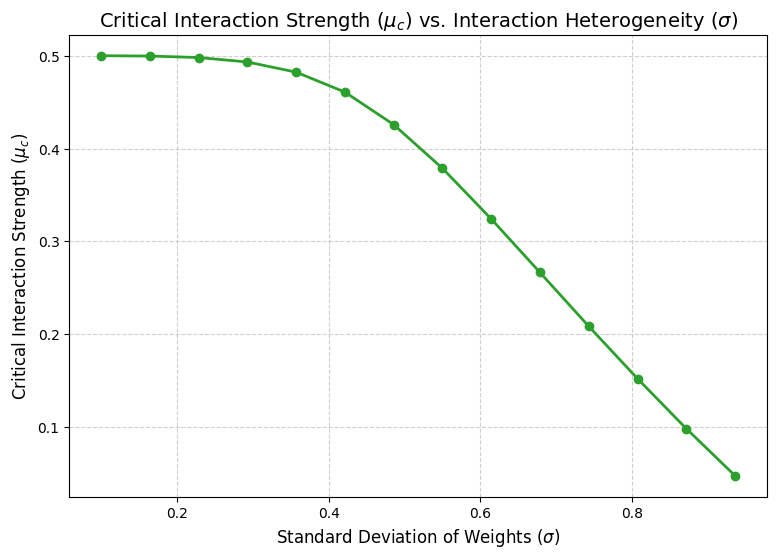

In [4]:
# Generate an array of sigma values from 0.1 to 1.0
sigmas_to_test = np.linspace(0.1, 1.0, 15)
calculated_mu_cs = []

print("Sweeping through sigma values to build plot...")
for s in sigmas_to_test:
    try:
        res = calculate_mu_c(sigma=s, gamma=0.0, nu_pdf=exponential_nu)
        calculated_mu_cs.append(res['mu_c'])
    except Exception:
        # If the solver fails to converge for a specific point, append NaN
        calculated_mu_cs.append(np.nan)

# Plot the results
plt.figure(figsize=(9, 6))
plt.plot(sigmas_to_test, calculated_mu_cs, marker='o', color='#2ca02c', linewidth=2)

plt.title(r'Critical Interaction Strength ($\mu_c$) vs. Interaction Heterogeneity ($\sigma$)', fontsize=14)
plt.xlabel(r'Standard Deviation of Weights ($\sigma$)', fontsize=12)
plt.ylabel(r'Critical Interaction Strength ($\mu_c$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()